# Análisis epidemiológico con reglas de asociación

Este notebook trabaja con el dataset **Diabetes Health Indicators Dataset** de Kaggle/BRFSS 2015. El enfoque del proyecto es **minería de reglas de asociación**, por lo tanto el análisis es no supervisado: no se define una variable objetivo, no se entrena un clasificador y no se evalúa desempeño predictivo.

El objetivo es descubrir patrones frecuentes e interpretables entre condiciones de salud, hábitos, factores clínicos y comorbilidades mediante dos algoritmos:

- Apriori
- FP-Growth


## Definición de problemas de reglas de asociación

En este proyecto se plantean problemas exploratorios propios de reglas de asociación:

1. Identificar combinaciones frecuentes de comorbilidades asociadas a diabetes o prediabetes, como hipertensión, colesterol alto, enfermedad cardíaca, dificultad para caminar u obesidad.
2. Detectar hábitos de vida que coocurren con factores clínicos de riesgo, por ejemplo tabaquismo, baja actividad física, consumo de frutas/verduras y consumo elevado de alcohol.
3. Encontrar perfiles frecuentes de pacientes con hipertensión, colesterol alto, obesidad o enfermedades cardíacas considerando edad, salud general, salud física, salud mental, educación e ingresos.

La salida esperada no son predicciones individuales, sino reglas del tipo `antecedente -> consecuente` evaluadas con soporte, confianza y lift.


## 1. Dependencias

Se instalan paquetes faltantes solo cuando el entorno no los tiene disponibles. `mlxtend` se utiliza para generar itemsets frecuentes y reglas de asociación.


In [5]:
import importlib
import subprocess
import sys
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

def install_if_missing(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

install_if_missing('mlxtend')
install_if_missing('pandas')
install_if_missing('numpy')
install_if_missing('matplotlib')
install_if_missing('seaborn')
install_if_missing('ipywidgets')

print('Dependencias listas')


Dependencias listas


## 2. Imports y configuración

Se cargan las librerías necesarias y se define una configuración visual básica.


In [6]:
import glob
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 160)
plt.rcParams['figure.figsize'] = (9, 5)
sns.set_theme(style='whitegrid')

print('Entorno importado')


Entorno importado


## 3. Carga del dataset

El notebook busca automáticamente un archivo CSV con la palabra `diabetes` en el directorio del proyecto. El archivo esperado es `diabetes_BRFSS2015.csv`.


In [7]:
candidates = sorted(set(glob.glob('*diabetes*.csv') + glob.glob('*Diabetes*.csv')))
if not candidates:
    raise FileNotFoundError('No se encontró un CSV con diabetes en el nombre dentro del directorio actual.')

data_path = candidates[0]
df = pd.read_csv(data_path)

print(f'Archivo leído: {data_path}')
print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]:,} columnas')
display(df.head())


Archivo leído: diabetes_BRFSS2015.csv
Dimensiones: 253,680 filas x 22 columnas


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 4. Exploración inicial

Esta revisión verifica estructura, tipos de datos, valores nulos y duplicados. En reglas de asociación los registros repetidos pueden representar múltiples encuestados con el mismo perfil, por lo que no se eliminan automáticamente.


In [8]:
df.info()

resumen_calidad = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'n_unicos': df.nunique()
})
display(resumen_calidad)

duplicados = int(df.duplicated().sum())
print(f'Registros duplicados exactos detectados: {duplicados:,}')
print('Se conservan porque cada fila representa una encuesta y aporta al cálculo de soporte.')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

,tipo,nulos,n_unicos
Diabetes_012,float64,0,3
HighBP,float64,0,2
HighChol,float64,0,2
CholCheck,float64,0,2
BMI,float64,0,84
Smoker,float64,0,2
Stroke,float64,0,2
HeartDiseaseorAttack,float64,0,2
PhysActivity,float64,0,2
Fruits,float64,0,2


Registros duplicados exactos detectados: 23,899
Se conservan porque cada fila representa una encuesta y aporta al cálculo de soporte.


## 5. Distribuciones descriptivas

Las siguientes tablas ayudan a entender las variables que luego se convertirán en ítems. `Diabetes_012` se conserva como una condición descriptiva, no como variable objetivo.


In [9]:
columnas_clave = ['Diabetes_012', 'HighBP', 'HighChol', 'BMI', 'Smoker', 'HeartDiseaseorAttack', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age']
display(df[columnas_clave].describe().T)

diabetes_labels = {0: 'sin_diabetes', 1: 'prediabetes', 2: 'diabetes'}
dist_diabetes = df['Diabetes_012'].map(diabetes_labels).value_counts(normalize=True).rename('proporcion').to_frame()
display(dist_diabetes)


,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
GenHlth,253680.0,2.511392,1.068477,1.0,2.0,2.0,3.0,5.0
MentHlth,253680.0,3.184772,7.412847,0.0,0.0,0.0,2.0,30.0
PhysHlth,253680.0,4.242081,8.717951,0.0,0.0,0.0,3.0,30.0
Age,253680.0,8.032119,3.054220,1.0,6.0,8.0,10.0,13.0


,proporcion
Diabetes_012,
sin_diabetes,0.842412
diabetes,0.139333
prediabetes,0.018255


## 6. Preparación transaccional

Para usar `mlxtend.frequent_patterns`, los datos deben estar en formato one-hot booleano: cada columna representa un ítem y cada fila una transacción.

Criterios aplicados:

- Las variables binarias se transforman solo cuando la condición está presente (`valor = 1`). No se crean ítems de ausencia como `no_fuma` o `no_diabetes`.
- `Diabetes_012` se representa únicamente como `prediabetes` o `diabetes` cuando esos estados están presentes. El valor 0 no se codifica para evitar reglas dominadas por ausencia de diabetes.
- `BMI`, `Age`, `MentHlth` y `PhysHlth` se discretizan en categorías interpretables.
- Variables ordinales como salud general, educación e ingresos se convierten en categorías.


In [16]:
df_work = df.copy()

# Convertir columnas a numérico
for col in df_work.columns:
    df_work[col] = pd.to_numeric(df_work[col], errors='coerce')

filas_antes = len(df_work)
df_work = df_work.dropna().copy()
filas_despues = len(df_work)
print(f'Filas removidas por nulos no convertibles: {filas_antes - filas_despues:,}')

# 1. Conservamos solo ítems clínicos y de hábitos biológicos de interés
# (Quitamos 'CholCheck', 'AnyHealthcare' y 'NoDocbcCost')
binary_items = {
    'HighBP': 'hipertension',
    'HighChol': 'colesterol_alto',
    'Smoker': 'fuma',
    'Stroke': 'derrame_cerebral',
    'HeartDiseaseorAttack': 'enfermedad_cardiaca_o_infarto',
    'PhysActivity': 'actividad_fisica',
    'Fruits': 'consume_frutas',
    'Veggies': 'consume_verduras',
    'HvyAlcoholConsump': 'consumo_alcohol_alto',
    'DiffWalk': 'dificultad_caminar'
}

genhlth_labels = {
    1: 'salud_general_excelente',
    2: 'salud_general_muy_buena',
    3: 'salud_general_buena',
    4: 'salud_general_regular',
    5: 'salud_general_mala'
}

def add_item(items, name, condition):
    items[name] = condition.fillna(False).astype(bool)

def add_mapped_category(items, source_col, labels):
    values = df_work[source_col].round().astype(int)
    for code, label in labels.items():
        add_item(items, label, values.eq(code))

def build_transactions_onehot():
    items = {}

    # Diagnóstico de diabetes (conservado como ítem)
    add_item(items, 'prediabetes', df_work['Diabetes_012'].eq(1))
    add_item(items, 'diabetes', df_work['Diabetes_012'].eq(2))

    # Mapeo de items clínicos y de hábitos
    for source_col, item_name in binary_items.items():
        add_item(items, item_name, df_work[source_col].eq(1))

    # Mapeo de rangos de BMI
    add_item(items, 'bmi_bajo_peso', df_work['BMI'].lt(18.5))
    add_item(items, 'bmi_normal', df_work['BMI'].between(18.5, 24.9, inclusive='both'))
    add_item(items, 'bmi_sobrepeso', df_work['BMI'].between(25, 29.9, inclusive='both'))
    add_item(items, 'bmi_obesidad_i', df_work['BMI'].between(30, 34.9, inclusive='both'))
    add_item(items, 'bmi_obesidad_ii', df_work['BMI'].between(35, 39.9, inclusive='both'))
    add_item(items, 'bmi_obesidad_iii', df_work['BMI'].ge(40))

    # Mapeo de salud física y mental
    add_item(items, 'mala_salud_mental_1_7_dias', df_work['MentHlth'].between(1, 7, inclusive='both'))
    add_item(items, 'mala_salud_mental_8_14_dias', df_work['MentHlth'].between(8, 14, inclusive='both'))
    add_item(items, 'mala_salud_mental_15_30_dias', df_work['MentHlth'].between(15, 30, inclusive='both'))
    add_item(items, 'mala_salud_fisica_1_7_dias', df_work['PhysHlth'].between(1, 7, inclusive='both'))
    add_item(items, 'mala_salud_fisica_8_14_dias', df_work['PhysHlth'].between(8, 14, inclusive='both'))
    add_item(items, 'mala_salud_fisica_15_30_dias', df_work['PhysHlth'].between(15, 30, inclusive='both'))

    # Mapeo de Salud General (GenHlth)
    add_mapped_category(items, 'GenHlth', genhlth_labels)

    # 2. Eliminamos los mapeos de 'Age' (Edad), 'Sex' (Sexo), 'Education' e 'Income'
    # (No se agregan a la lista de items)

    onehot = pd.DataFrame(items, index=df_work.index).astype(bool)
    onehot = onehot.loc[:, onehot.any(axis=0)]
    return onehot

df_onehot = build_transactions_onehot()

print(f'Matriz one-hot: {df_onehot.shape[0]:,} transacciones x {df_onehot.shape[1]:,} ítems')
display(df_onehot.head())

Filas removidas por nulos no convertibles: 0
Matriz one-hot: 253,680 transacciones x 29 ítems


,prediabetes,diabetes,hipertension,colesterol_alto,fuma,derrame_cerebral,enfermedad_cardiaca_o_infarto,actividad_fisica,consume_frutas,consume_verduras,consumo_alcohol_alto,dificultad_caminar,bmi_bajo_peso,bmi_normal,bmi_sobrepeso,bmi_obesidad_i,bmi_obesidad_ii,bmi_obesidad_iii,mala_salud_mental_1_7_dias,mala_salud_mental_8_14_dias,mala_salud_mental_15_30_dias,mala_salud_fisica_1_7_dias,mala_salud_fisica_8_14_dias,mala_salud_fisica_15_30_dias,salud_general_excelente,salud_general_muy_buena,salud_general_buena,salud_general_regular,salud_general_mala
0,False,False,True,True,True,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,True
1,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,True,True,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True
3,False,False,True,False,False,False,False,True,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,True,True,False,False,False,True,True,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False


### Ejemplo de transacciones

Cada fila del dataset se interpreta como una transacción compuesta por los ítems verdaderos para ese encuestado.


In [ ]:
transactions_preview = df_onehot.head(5).apply(lambda row: sorted(row.index[row].tolist()), axis=1)
for idx, transaction in transactions_preview.items():
    print(f'Transacción {idx}: {transaction}')


Transacción 0: ['bmi_obesidad_iii', 'colesterol_alto', 'consume_verduras', 'dificultad_caminar', 'fuma', 'hipertension', 'mala_salud_fisica_15_30_dias', 'mala_salud_mental_15_30_dias', 'salud_general_mala']
Transacción 1: ['actividad_fisica', 'bmi_sobrepeso', 'fuma', 'salud_general_buena']
Transacción 2: ['bmi_sobrepeso', 'colesterol_alto', 'consume_frutas', 'dificultad_caminar', 'hipertension', 'mala_salud_fisica_15_30_dias', 'mala_salud_mental_15_30_dias', 'salud_general_mala']
Transacción 3: ['actividad_fisica', 'bmi_sobrepeso', 'consume_frutas', 'consume_verduras', 'hipertension', 'salud_general_muy_buena']
Transacción 4: ['actividad_fisica', 'bmi_normal', 'colesterol_alto', 'consume_frutas', 'consume_verduras', 'hipertension', 'mala_salud_mental_1_7_dias', 'salud_general_muy_buena']


### Frecuencia individual de ítems

Antes de aplicar Apriori y FP-Growth se revisan los ítems más frecuentes. Esto ayuda a justificar un soporte mínimo que no sea ni demasiado laxo ni demasiado restrictivo.


,support
consume_verduras,0.811420
actividad_fisica,0.756544
consume_frutas,0.634256
fuma,0.443169
hipertension,0.429001
colesterol_alto,0.424121
bmi_sobrepeso,0.369556
salud_general_muy_buena,0.351167
salud_general_buena,0.298195
bmi_normal,0.271811


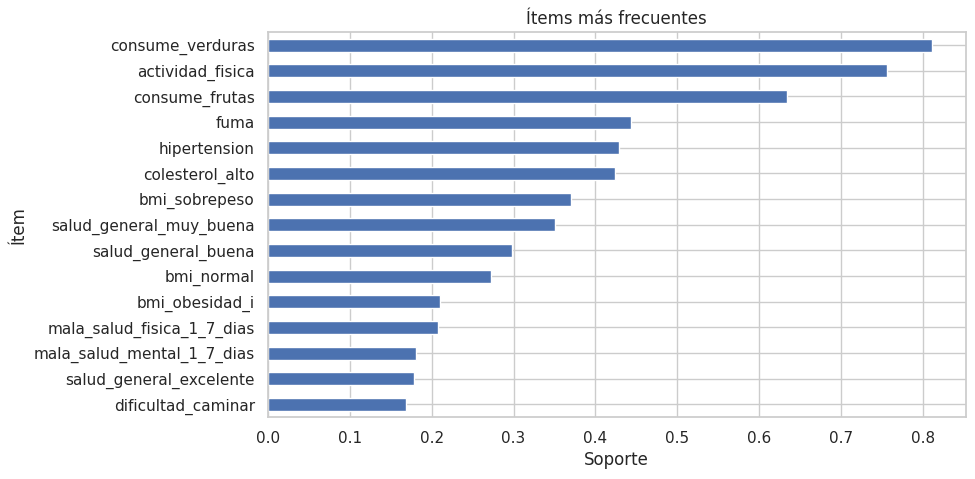

In [ ]:
item_support = df_onehot.mean().sort_values(ascending=False).rename('support').to_frame()
display(item_support.head(20))

ax = item_support.head(15).sort_values('support').plot(kind='barh', legend=False)
ax.set_xlabel('Soporte')
ax.set_ylabel('Ítem')
ax.set_title('Ítems más frecuentes')
plt.show()


## 7. Criterios de filtrado de reglas

Se usan criterios explícitos para ambos modelos:

- `min_support = 0.03`: el patrón debe aparecer en al menos 3% de las transacciones. Con más de 250 mil registros, este umbral conserva patrones frecuentes y evita combinaciones demasiado raras.
- `min_confidence = 0.60`: se conservan reglas cuyo consecuente aparece en al menos 60% de las transacciones que contienen el antecedente.
- `lift > 1`: se retienen reglas con asociación positiva frente a la independencia estadística.
- `max_len = 4`: limita el tamaño de los itemsets para mantener reglas interpretables y tiempos de ejecución razonables.


In [ ]:
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.60
MAX_LEN = 4

print(f'min_support={MIN_SUPPORT}, min_confidence={MIN_CONFIDENCE}, lift > 1, max_len={MAX_LEN}')


min_support=0.03, min_confidence=0.6, lift > 1, max_len=4


## 8. Funciones para generar y exportar reglas

Las funciones siguientes ejecutan cada algoritmo, generan reglas con `association_rules`, filtran por `lift > 1`, ordenan por lift, confianza y soporte, y preparan una versión exportable a CSV.


In [ ]:
def itemset_to_text(itemset):
    return ', '.join(sorted(itemset))

def prepare_rules_for_export(rules_df):
    rules_export = rules_df.copy()
    rules_export['antecedents'] = rules_export['antecedents'].apply(itemset_to_text)
    rules_export['consequents'] = rules_export['consequents'].apply(itemset_to_text)
    return rules_export

def get_association_rules(frequent_itemsets):
    if frequent_itemsets.empty:
        return pd.DataFrame()

    rules_df = association_rules(frequent_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE)
    if rules_df.empty:
        return rules_df

    rules_df = rules_df[rules_df['lift'] > 1].copy()
    rules_df = rules_df.sort_values(['lift', 'confidence', 'support'], ascending=False).reset_index(drop=True)
    return rules_df

def run_algorithm(algorithm_name, algorithm_func, output_csv):
    start = time.perf_counter()
    frequent_itemsets = algorithm_func(
        df_onehot,
        min_support=MIN_SUPPORT,
        use_colnames=True,
        max_len=MAX_LEN
    )
    elapsed = time.perf_counter() - start

    frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)
    rules_df = get_association_rules(frequent_itemsets)
    rules_export = prepare_rules_for_export(rules_df) if not rules_df.empty else rules_df
    rules_export.to_csv(output_csv, index=False)

    print(f'{algorithm_name}: {len(frequent_itemsets):,} itemsets frecuentes')
    print(f'{algorithm_name}: {len(rules_df):,} reglas filtradas')
    print(f'{algorithm_name}: {elapsed:.2f} segundos')
    print(f'Archivo exportado: {output_csv}')

    return frequent_itemsets, rules_df, elapsed


## 9. Modelo 1: Apriori

Apriori genera candidatos de itemsets frecuentes de forma iterativa. Se aplica sobre la matriz one-hot y luego se derivan reglas de asociación.


In [ ]:
itemsets_apriori, reglas_apriori, tiempo_apriori = run_algorithm(
    'Apriori',
    apriori,
    'reglas_apriori.csv'
)

display(prepare_rules_for_export(reglas_apriori).head(20))


Apriori: 811 itemsets frecuentes
Apriori: 730 reglas filtradas
Apriori: 1.61 segundos
Archivo exportado: reglas_apriori.csv


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,salud_general_mala,"dificultad_caminar, mala_salud_fisica_15_30_dias",0.047623,0.075367,0.030586,0.642248,8.521655,1.0,0.026997,2.584566,0.926788,0.331001,0.613088,0.524037
1,"dificultad_caminar, salud_general_mala",mala_salud_fisica_15_30_dias,0.035718,0.122489,0.030586,0.856307,6.990893,1.0,0.026211,6.106857,0.888700,0.239660,0.836250,0.553005
2,salud_general_mala,mala_salud_fisica_15_30_dias,0.047623,0.122489,0.038773,0.814171,6.646893,1.0,0.032940,4.722143,0.892035,0.295216,0.788232,0.565358
3,"mala_salud_fisica_15_30_dias, salud_general_mala",dificultad_caminar,0.038773,0.168224,0.030586,0.788837,4.689213,1.0,0.024063,3.939023,0.818480,0.173378,0.746130,0.485326
4,salud_general_mala,dificultad_caminar,0.047623,0.168224,0.035718,0.750021,4.458471,1.0,0.027707,3.327380,0.814497,0.198293,0.699463,0.481173
5,"fuma, hipertension, mala_salud_fisica_15_30_dias",dificultad_caminar,0.045699,0.168224,0.031946,0.699043,4.155433,1.0,0.024258,2.763767,0.795715,0.175548,0.638175,0.444471
6,"colesterol_alto, hipertension, mala_salud_fisica_15_30_dias",dificultad_caminar,0.051695,0.168224,0.035773,0.692009,4.113620,1.0,0.027077,2.700647,0.798166,0.194267,0.629718,0.452331
7,"hipertension, mala_salud_fisica_15_30_dias",dificultad_caminar,0.076277,0.168224,0.051459,0.674625,4.010286,1.0,0.038627,2.556364,0.812626,0.266566,0.608819,0.490259
8,"consume_verduras, hipertension, mala_salud_fisica_15_30_dias",dificultad_caminar,0.056043,0.168224,0.037098,0.661954,3.934962,1.0,0.027670,2.460542,0.790150,0.198206,0.593585,0.441241
9,"colesterol_alto, mala_salud_fisica_15_30_dias",dificultad_caminar,0.069848,0.168224,0.045885,0.656922,3.905049,1.0,0.034135,2.424452,0.799784,0.238750,0.587536,0.464841


## 10. Modelo 2: FP-Growth

FP-Growth evita la generación explícita de candidatos mediante una estructura FP-tree. Suele ser más eficiente que Apriori en datasets grandes.


In [ ]:
itemsets_fpgrowth, reglas_fpgrowth, tiempo_fpgrowth = run_algorithm(
    'FP-Growth',
    fpgrowth,
    'reglas_fpgrowth.csv'
)

display(prepare_rules_for_export(reglas_fpgrowth).head(20))


FP-Growth: 811 itemsets frecuentes
FP-Growth: 730 reglas filtradas
FP-Growth: 496.33 segundos
Archivo exportado: reglas_fpgrowth.csv


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,salud_general_mala,"dificultad_caminar, mala_salud_fisica_15_30_dias",0.047623,0.075367,0.030586,0.642248,8.521655,1.0,0.026997,2.584566,0.926788,0.331001,0.613088,0.524037
1,"dificultad_caminar, salud_general_mala",mala_salud_fisica_15_30_dias,0.035718,0.122489,0.030586,0.856307,6.990893,1.0,0.026211,6.106857,0.888700,0.239660,0.836250,0.553005
2,salud_general_mala,mala_salud_fisica_15_30_dias,0.047623,0.122489,0.038773,0.814171,6.646893,1.0,0.032940,4.722143,0.892035,0.295216,0.788232,0.565358
3,"mala_salud_fisica_15_30_dias, salud_general_mala",dificultad_caminar,0.038773,0.168224,0.030586,0.788837,4.689213,1.0,0.024063,3.939023,0.818480,0.173378,0.746130,0.485326
4,salud_general_mala,dificultad_caminar,0.047623,0.168224,0.035718,0.750021,4.458471,1.0,0.027707,3.327380,0.814497,0.198293,0.699463,0.481173
5,"fuma, hipertension, mala_salud_fisica_15_30_dias",dificultad_caminar,0.045699,0.168224,0.031946,0.699043,4.155433,1.0,0.024258,2.763767,0.795715,0.175548,0.638175,0.444471
6,"colesterol_alto, hipertension, mala_salud_fisica_15_30_dias",dificultad_caminar,0.051695,0.168224,0.035773,0.692009,4.113620,1.0,0.027077,2.700647,0.798166,0.194267,0.629718,0.452331
7,"hipertension, mala_salud_fisica_15_30_dias",dificultad_caminar,0.076277,0.168224,0.051459,0.674625,4.010286,1.0,0.038627,2.556364,0.812626,0.266566,0.608819,0.490259
8,"consume_verduras, hipertension, mala_salud_fisica_15_30_dias",dificultad_caminar,0.056043,0.168224,0.037098,0.661954,3.934962,1.0,0.027670,2.460542,0.790150,0.198206,0.593585,0.441241
9,"colesterol_alto, mala_salud_fisica_15_30_dias",dificultad_caminar,0.069848,0.168224,0.045885,0.656922,3.905049,1.0,0.034135,2.424452,0.799784,0.238750,0.587536,0.464841


## 11. Comparación entre Apriori y FP-Growth

Se comparan cantidad de itemsets frecuentes, cantidad de reglas generadas, tiempo de ejecución y coincidencias entre las mejores reglas. Dado que ambos algoritmos usan los mismos datos y umbrales, deberían encontrar los mismos itemsets y reglas; la diferencia principal esperada está en el tiempo de ejecución.


,modelo,itemsets_frecuentes,reglas_generadas,tiempo_segundos
0,Apriori,811,730,1.610776
1,FP-Growth,811,730,496.325262


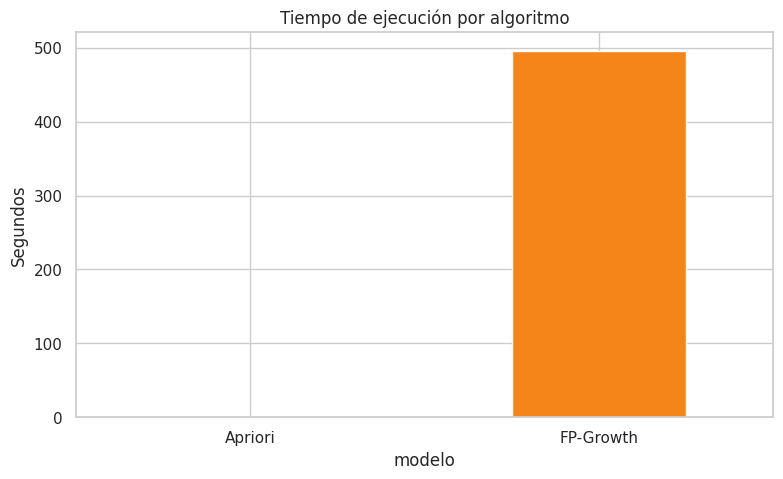

In [ ]:
comparison = pd.DataFrame([
    {
        'modelo': 'Apriori',
        'itemsets_frecuentes': len(itemsets_apriori),
        'reglas_generadas': len(reglas_apriori),
        'tiempo_segundos': tiempo_apriori
    },
    {
        'modelo': 'FP-Growth',
        'itemsets_frecuentes': len(itemsets_fpgrowth),
        'reglas_generadas': len(reglas_fpgrowth),
        'tiempo_segundos': tiempo_fpgrowth
    }
])

display(comparison)

ax = comparison.set_index('modelo')['tiempo_segundos'].plot(kind='bar', color=['#4C78A8', '#F58518'])
ax.set_ylabel('Segundos')
ax.set_title('Tiempo de ejecución por algoritmo')
plt.xticks(rotation=0)
plt.show()


### Similitudes y diferencias entre las mejores reglas

La comparación se realiza con las reglas mejor posicionadas por lift, confianza y soporte. Para comparar coincidencias se usa la firma `antecedentes -> consecuentes`.


In [ ]:
def add_rule_signature(rules_df):
    rules_text = prepare_rules_for_export(rules_df)
    if rules_text.empty:
        rules_text['regla'] = []
        return rules_text
    rules_text['regla'] = rules_text['antecedents'] + ' -> ' + rules_text['consequents']
    return rules_text

top_n = 20
top_apriori = add_rule_signature(reglas_apriori).head(top_n)
top_fpgrowth = add_rule_signature(reglas_fpgrowth).head(top_n)

common_rules = sorted(set(top_apriori['regla']).intersection(set(top_fpgrowth['regla'])))
only_apriori = sorted(set(top_apriori['regla']).difference(set(top_fpgrowth['regla'])))
only_fpgrowth = sorted(set(top_fpgrowth['regla']).difference(set(top_apriori['regla'])))

print(f'Reglas comunes en el top {top_n}: {len(common_rules)}')
display(pd.DataFrame({'reglas_comunes': common_rules[:10]}))

print(f'Reglas solo en top Apriori: {len(only_apriori)}')
display(pd.DataFrame({'solo_top_apriori': only_apriori[:10]}))

print(f'Reglas solo en top FP-Growth: {len(only_fpgrowth)}')
display(pd.DataFrame({'solo_top_fpgrowth': only_fpgrowth[:10]}))


Reglas comunes en el top 20: 20


,reglas_comunes
0,"colesterol_alto, consume_verduras, mala_salud_fisica_15_30_dias -> dificultad_caminar"
1,"colesterol_alto, diabetes, dificultad_caminar -> hipertension"
2,"colesterol_alto, enfermedad_cardiaca_o_infarto -> hipertension"
3,"colesterol_alto, enfermedad_cardiaca_o_infarto, fuma -> hipertension"
4,"colesterol_alto, hipertension, mala_salud_fisica_15_30_dias -> dificultad_caminar"
5,"colesterol_alto, mala_salud_fisica_15_30_dias -> dificultad_caminar"
6,"consume_verduras, diabetes, dificultad_caminar -> hipertension"
7,"consume_verduras, fuma, mala_salud_fisica_15_30_dias -> dificultad_caminar"
8,"consume_verduras, hipertension, mala_salud_fisica_15_30_dias -> dificultad_caminar"
9,"diabetes, dificultad_caminar -> colesterol_alto, hipertension"


Reglas solo en top Apriori: 0


,solo_top_apriori


Reglas solo en top FP-Growth: 0


,solo_top_fpgrowth


## 12. Interpretación de reglas destacadas

La tabla siguiente consolida las mejores reglas de ambos modelos. Para interpretarlas:

- **Soporte**: proporción de encuestados que contienen antecedente y consecuente.
- **Confianza**: probabilidad empírica del consecuente cuando aparece el antecedente.
- **Lift**: valores mayores a 1 indican asociación positiva respecto a la independencia.

Una regla con alto lift no implica causalidad; solo evidencia coocurrencia frecuente bajo los filtros definidos.


In [ ]:
best_rules = pd.concat([
    add_rule_signature(reglas_apriori).assign(modelo='Apriori').head(10),
    add_rule_signature(reglas_fpgrowth).assign(modelo='FP-Growth').head(10)
], ignore_index=True)

cols_to_show = ['modelo', 'regla', 'support', 'confidence', 'lift', 'leverage', 'conviction']
display(best_rules[cols_to_show])


,modelo,regla,support,confidence,lift,leverage,conviction
0,Apriori,"salud_general_mala -> dificultad_caminar, mala_salud_fisica_15_30_dias",0.030586,0.642248,8.521655,0.026997,2.584566
1,Apriori,"dificultad_caminar, salud_general_mala -> mala_salud_fisica_15_30_dias",0.030586,0.856307,6.990893,0.026211,6.106857
2,Apriori,salud_general_mala -> mala_salud_fisica_15_30_dias,0.038773,0.814171,6.646893,0.032940,4.722143
3,Apriori,"mala_salud_fisica_15_30_dias, salud_general_mala -> dificultad_caminar",0.030586,0.788837,4.689213,0.024063,3.939023
4,Apriori,salud_general_mala -> dificultad_caminar,0.035718,0.750021,4.458471,0.027707,3.327380
5,Apriori,"fuma, hipertension, mala_salud_fisica_15_30_dias -> dificultad_caminar",0.031946,0.699043,4.155433,0.024258,2.763767
6,Apriori,"colesterol_alto, hipertension, mala_salud_fisica_15_30_dias -> dificultad_caminar",0.035773,0.692009,4.113620,0.027077,2.700647
7,Apriori,"hipertension, mala_salud_fisica_15_30_dias -> dificultad_caminar",0.051459,0.674625,4.010286,0.038627,2.556364
8,Apriori,"consume_verduras, hipertension, mala_salud_fisica_15_30_dias -> dificultad_caminar",0.037098,0.661954,3.934962,0.027670,2.460542
9,Apriori,"colesterol_alto, mala_salud_fisica_15_30_dias -> dificultad_caminar",0.045885,0.656922,3.905049,0.034135,2.424452


## 13. Archivos exportados

Al ejecutar el notebook se generan dos archivos CSV separados con las reglas filtradas y ordenadas:

- `reglas_apriori.csv`
- `reglas_fpgrowth.csv`


In [ ]:
for file_name in ['reglas_apriori.csv', 'reglas_fpgrowth.csv']:
    path = Path(file_name)
    if path.exists():
        print(f'{file_name}: {path.stat().st_size:,} bytes')
    else:
        print(f'{file_name}: no encontrado')


reglas_apriori.csv: 206,173 bytes
reglas_fpgrowth.csv: 206,173 bytes


## 14. Conclusiones

Apriori y FP-Growth permiten descubrir reglas de asociación entre condiciones de salud, hábitos, factores clínicos y características sociodemográficas del dataset BRFSS 2015. Ambos modelos trabajan sobre una representación transaccional one-hot y producen reglas interpretables evaluadas con soporte, confianza y lift.

Este proyecto no entrena un modelo predictivo tradicional. No se define una variable objetivo, no se divide el dataset en entrenamiento y prueba, y no se reportan métricas de clasificación. `Diabetes_012` se trata como un ítem descriptivo para identificar coocurrencias con diabetes o prediabetes, no como etiqueta a predecir.

El resultado principal son reglas interpretables, no predicciones individuales. Estas reglas pueden servir como insumo exploratorio para comprender perfiles frecuentes de riesgo, orientar análisis epidemiológicos posteriores o alimentar futuras hipótesis y modelos supervisados. Sin embargo, no reemplazan un modelo de clasificación ni permiten afirmar causalidad.


## 15. Explorador Interactivo de Reglas Epidemiológicas

Esta sección agrega controles dinámicos para filtrar las reglas de asociación generadas con FP-Growth y encontrar rápidamente las combinaciones más relevantes para el proyecto según soporte, confianza, lift y tamaño total de la regla.


In [10]:
import pandas as pd

df_explorador = pd.read_csv('reglas_fpgrowth.csv')

df_explorador['rule_size'] = (
    df_explorador['antecedents'].astype(str).str.count(',') + 1
    + df_explorador['consequents'].astype(str).str.count(',') + 1
)

print(f'Reglas cargadas para exploración: {len(df_explorador):,}')
display(df_explorador[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'rule_size']].head())


Reglas cargadas para exploración: 730


,antecedents,consequents,support,confidence,lift,rule_size
0,salud_general_mala,"dificultad_caminar, mala_salud_fisica_15_30_dias",0.030586,0.642248,8.521655,3
1,"dificultad_caminar, salud_general_mala",mala_salud_fisica_15_30_dias,0.030586,0.856307,6.990893,3
2,salud_general_mala,mala_salud_fisica_15_30_dias,0.038773,0.814171,6.646893,2
3,"mala_salud_fisica_15_30_dias, salud_general_mala",dificultad_caminar,0.030586,0.788837,4.689213,3
4,salud_general_mala,dificultad_caminar,0.035718,0.750021,4.458471,2


In [11]:
import ipywidgets as widgets
from IPython.display import Markdown, display

columnas_explorador = ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'rule_size']

def explorar_reglas_epidemiologicas(min_support, min_confidence, min_lift, max_rule_size):
    reglas_filtradas = df_explorador[
        (df_explorador['support'] >= min_support)
        & (df_explorador['confidence'] >= min_confidence)
        & (df_explorador['lift'] >= min_lift)
        & (df_explorador['rule_size'] <= max_rule_size)
    ].copy()

    reglas_filtradas = reglas_filtradas.sort_values(
        ['lift', 'confidence'],
        ascending=False
    )

    display(Markdown(f'**Total de Reglas Encontradas: {len(reglas_filtradas)}**'))
    display(reglas_filtradas[columnas_explorador].reset_index(drop=True))

widgets.interact(
    explorar_reglas_epidemiologicas,
    min_support=widgets.FloatSlider(
        value=0.04, min=0.01, max=0.15, step=0.01,
        description='Min support', readout_format='.2f', continuous_update=False
    ),
    min_confidence=widgets.FloatSlider(
        value=0.70, min=0.40, max=1.00, step=0.05,
        description='Min confidence', readout_format='.2f', continuous_update=False
    ),
    min_lift=widgets.FloatSlider(
        value=1.5, min=1.0, max=5.0, step=0.1,
        description='Min lift', readout_format='.1f', continuous_update=False
    ),
    max_rule_size=widgets.IntSlider(
        value=4, min=2, max=6, step=1,
        description='Max rule size', continuous_update=False
    )
)


interactive(children=(FloatSlider(value=0.04, continuous_update=False, description='Min support', max=0.15, mi…

<function __main__.explorar_reglas_epidemiologicas(min_support, min_confidence, min_lift, max_rule_size)>

## 16. Experimento de Rendimiento y Escalabilidad (Barrido de Soporte)

Esta celda ejecuta el experimento formal del proyecto: evalúa de manera consecutiva los algoritmos **Apriori** y **FP-Growth** bajo diferentes umbrales de soporte mínimo (`0.10`, `0.05`, `0.03`, `0.02`), midiendo el tiempo de ejecución en segundos y el crecimiento del número de itemsets frecuentes para demostrar el impacto de la explosión combinatoria.

Iniciando experimento de rendimiento...
Evaluando escenario con min_support = 0.1...
Evaluando escenario con min_support = 0.05...
Evaluando escenario con min_support = 0.03...
Evaluando escenario con min_support = 0.02...

=== Resultados del Experimento ===


,min_support,itemsets_frecuentes,reglas_generadas,tiempo_apriori_seg,tiempo_fpgrowth_seg
0,0.10,157,165,0.2637,84.0506
1,0.05,435,392,0.7896,248.2944
2,0.03,811,730,1.9164,477.0526
3,0.02,1275,1034,2.7589,753.7672


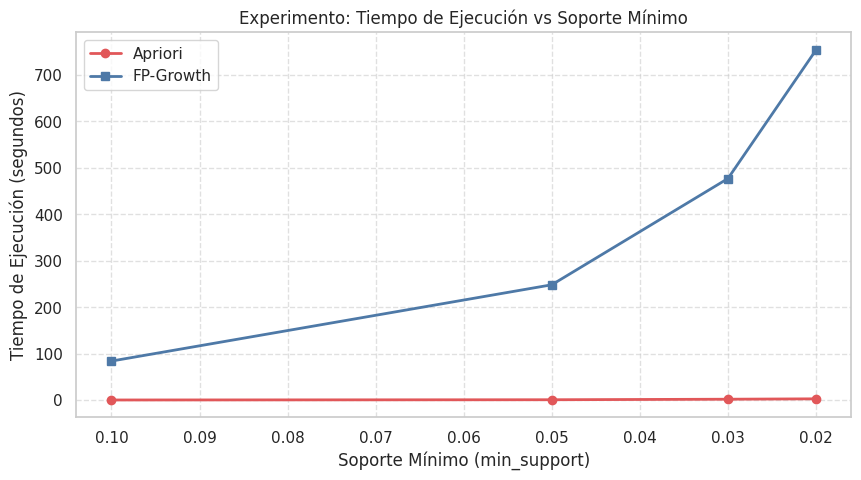

In [17]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# 1. Definir los umbrales de soporte a evaluar
soportes_evaluar = [0.10, 0.05, 0.03, 0.02]
resultados_experimento = []

print("Iniciando experimento de rendimiento...")

for sup in soportes_evaluar:
    print(f"Evaluando escenario con min_support = {sup}...")

    # Evaluar Apriori
    start_ap = time.perf_counter()
    itemsets_ap = apriori(df_onehot, min_support=sup, use_colnames=True, max_len=4)
    if not itemsets_ap.empty:
        reglas_ap = association_rules(itemsets_ap, metric='confidence', min_threshold=0.60)
        num_reglas_ap = len(reglas_ap[reglas_ap['lift'] > 1])
    else:
        num_reglas_ap = 0
    elapsed_ap = time.perf_counter() - start_ap

    # Evaluar FP-Growth
    start_fp = time.perf_counter()
    itemsets_fp = fpgrowth(df_onehot, min_support=sup, use_colnames=True, max_len=4)
    if not itemsets_fp.empty:
        reglas_fp = association_rules(itemsets_fp, metric='confidence', min_threshold=0.60)
        num_reglas_fp = len(reglas_fp[reglas_fp['lift'] > 1])
    else:
        num_reglas_fp = 0
    elapsed_fp = time.perf_counter() - start_fp

    resultados_experimento.append({
        'min_support': sup,
        'itemsets_frecuentes': len(itemsets_ap),
        'reglas_generadas': num_reglas_ap,
        'tiempo_apriori_seg': round(elapsed_ap, 4),
        'tiempo_fpgrowth_seg': round(elapsed_fp, 4)
    })

# 2. Convertir resultados a DataFrame
df_resultados = pd.DataFrame(resultados_experimento)
print("\n=== Resultados del Experimento ===")
display(df_resultados)

# 3. Graficar la comparación de tiempos
plt.figure(figsize=(10, 5))
plt.plot(df_resultados['min_support'], df_resultados['tiempo_apriori_seg'], marker='o', color='#E15759', linewidth=2, label='Apriori')
plt.plot(df_resultados['min_support'], df_resultados['tiempo_fpgrowth_seg'], marker='s', color='#4E79A7', linewidth=2, label='FP-Growth')
plt.xlabel('Soporte Mínimo (min_support)')
plt.ylabel('Tiempo de Ejecución (segundos)')
plt.title('Experimento: Tiempo de Ejecución vs Soporte Mínimo')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.gca().invert_xaxis()  # Invertir eje X para ver de soporte alto a bajo (carrera más difícil)
plt.show()